<a href="https://colab.research.google.com/github/ddy623/Kaggle-Projects/blob/main/Space_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# Project README

## Purpose
This notebook analyzes the `train.csv` dataset from the Spaceship Titanic competition to explore factors influencing whether passengers were 'Transported' to another dimension.

## Data
The dataset `train.csv` contains various passenger information, including:
- `PassengerId`: A unique identifier for each passenger.
- `HomePlanet`: The planet the passenger originally came from.
- `CryoSleep`: Whether the passenger opted for cryosleep during the voyage.
- `Cabin`: The cabin number where the passenger was staying.
- `Destination`: The planet the passenger was heading to.
- `Age`: The age of the passenger.
- `VIP`: Whether the passenger has VIP status.
- `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`: Amount spent on various amenities.
- `Name`: The first and last name of the passenger.
- `Transported`: The target variable, indicating if the passenger was transported to another dimension (True) or not (False).

Missing values were imputed using medians for numerical columns and modes for categorical columns. New features like 'Deck' and 'AgeGroup' were engineered.

## Key Findings
- **CryoSleep:** Passengers in cryosleep had a significantly higher transportation rate (around 81%) compared to those who were not (around 33%). This was identified as the most important feature by both Random Forest and XGBoost models.
- **HomePlanet:** Europa had the highest transport rate, followed by Mars, and then Earth. Passengers from Europa were more likely to be transported.
- **Cabin Deck:** Passengers in 'premium' decks (B and C) showed higher transportation rates. Deck G also had a higher rate.
- **Age Group:** Children were more likely to be transported than any other age group.
- **VIP Status:** Non-VIP passengers were slightly more likely to be transported than VIP passengers.
- **Amenity Spending:** High spending on amenities like RoomService, FoodCourt, ShoppingMall, Spa, and VRDeck generally correlated with a lower likelihood of being transported, with `Spa` and `VRDeck` being moderately important features.
- **Model Performance:** A Random Forest Classifier achieved a validation accuracy of approximately 81.08%, while a tuned Random Forest model achieved 79.41%. XGBoost also provided similar insights into feature importance.

## Conclusion
The analysis suggests that factors like `CryoSleep` status, `HomePlanet`, `Cabin Deck`, and `Age` are strong indicators for predicting whether a passenger was transported. The engineered `Num` feature (from the Cabin number) also emerged as a highly influential factor in the Random Forest model.
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data Science Project/train.csv'
df = pd.read_csv(file_path)
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
df.describe ()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [ ]:
df.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [ ]:
import pandas as pd

# Reload the original training data into df to ensure correct dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Science Project/train.csv')

numerical_cols_to_impute = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in numerical_cols_to_impute:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

categorical_cols_to_impute = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin', 'Name']
for col in categorical_cols_to_impute:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

print("Missing values after imputation:")
display(df.isnull().sum())

Missing values after imputation:


/tmp/ipykernel_1654/891266083.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_val)


,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Cabin,0
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0


In [ ]:
df['HomePlanet'].value_counts()

,count
HomePlanet,
Earth,4803
Europa,2131
Mars,1759


the data shows that the majority of the passengers are from Earth.

In [ ]:
df[['HomePlanet', 'PassengerId', 'Destination', 'Transported']].head()

,HomePlanet,PassengerId,Destination,Transported
0,Europa,0001_01,TRAPPIST-1e,False
1,Earth,0002_01,TRAPPIST-1e,True
2,Europa,0003_01,TRAPPIST-1e,False
3,Europa,0003_02,TRAPPIST-1e,False
4,Earth,0004_01,TRAPPIST-1e,True


In [ ]:
transport_rate_by_homeplanet = df.groupby('HomePlanet')['Transported'].mean().reset_index()
display(transport_rate_by_homeplanet)

,HomePlanet,Transported
0,Earth,0.427649
1,Europa,0.658846
2,Mars,0.523024


/tmp/ipykernel_1654/1145169388.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='HomePlanet', y='Transported', data=transport_rate_by_homeplanet, palette='viridis')


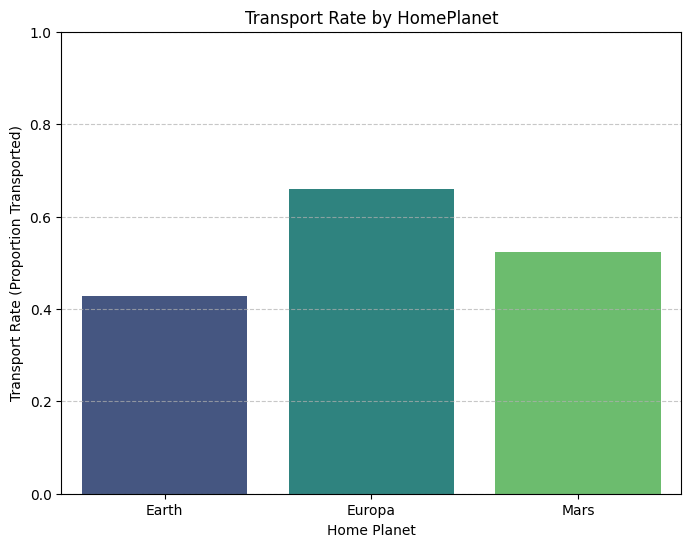

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='HomePlanet', y='Transported', data=transport_rate_by_homeplanet, palette='viridis')
plt.title('Transport Rate by HomePlanet')
plt.xlabel('Home Planet')
plt.ylabel('Transport Rate (Proportion Transported)')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for proportion
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Based upon the data, Europa has the highest transport rate, followed by Mars and then Earth.

Is there a correlation with the deck chosen and a person being transported?

In [ ]:
df['Deck'] = df['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'Unknown')
deck_transport_rate = df.groupby('Deck')['Transported'].mean().reset_index()
display(deck_transport_rate)
print("Decks B and C were considered 'premium' as they had the highest transport rates among all decks.")

,Deck,Transported
0,A,0.496094
1,B,0.734275
2,C,0.680054
3,D,0.433054
4,E,0.357306
5,F,0.439871
6,G,0.515228
7,T,0.200000


Decks B and C were considered 'premium' as they had the highest transport rates among all decks.


In [ ]:
premium_decks = ['B', 'C']

# Filter for passengers in premium decks using df
df_premium_decks = df[df['Deck'].isin(premium_decks)].copy()

# Count people in premium decks
num_people_premium_decks = df_premium_decks.shape[0]
print(f"Number of people in premium decks (B and C): {num_people_premium_decks}")

# Calculate average amenity usage for people in premium decks
amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
average_amenities_premium = df_premium_decks[amenities].mean()

print("\nAverage amenity usage for people in premium decks:")
display(average_amenities_premium)

Number of people in premium decks (B and C): 1526

Average amenity usage for people in premium decks:


,0
RoomService,130.098296
FoodCourt,1507.814548
ShoppingMall,159.978375
Spa,807.924640
VRDeck,898.701835


Is there a correlation with cabin size and a person being transported?

In [ ]:
# Extract the deck from the 'Cabin' column (e.g., 'B/0/P' -> 'B')
# Fill NaN values in 'Cabin' with 'Unknown' before extracting the first letter
df['Deck'] = df['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'Unknown')

# Calculate the transport rate by 'Deck'
deck_transport_rate = df.groupby('Deck')['Transported'].mean().reset_index()
display(deck_transport_rate)

,Deck,Transported
0,A,0.496094
1,B,0.734275
2,C,0.680054
3,D,0.433054
4,E,0.357306
5,F,0.439871
6,G,0.515228
7,T,0.200000


/tmp/ipykernel_1654/2976795483.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Deck', y='Transported', data=deck_transport_rate, palette='viridis')


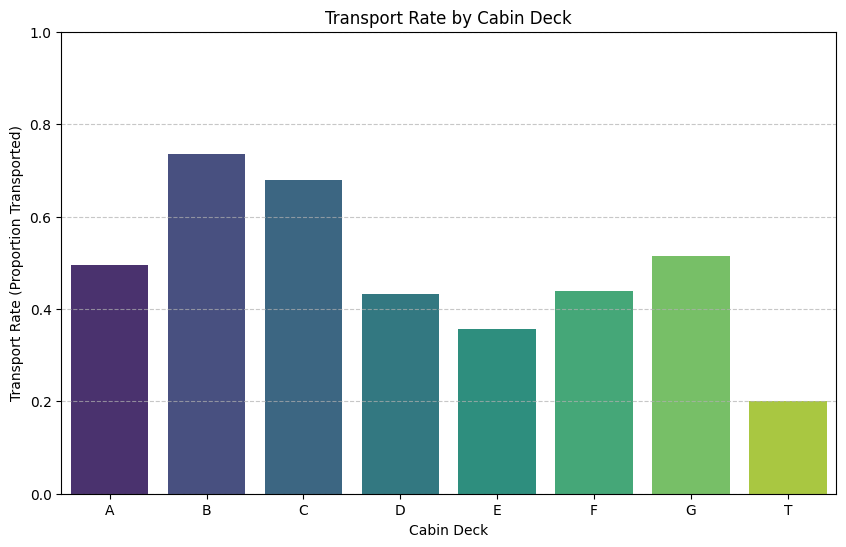

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Deck', y='Transported', data=deck_transport_rate, palette='viridis')
plt.title('Transport Rate by Cabin Deck')
plt.xlabel('Cabin Deck')
plt.ylabel('Transport Rate (Proportion Transported)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Deck B and C were more likely to be transported than any other deck.

### Correlation between VIP Status and Transported Status

In [ ]:
# Calculate the transport rate by 'VIP' status
vip_transport_rate = df.groupby('VIP')['Transported'].mean().reset_index()
display(vip_transport_rate)

,VIP,Transported
0,False,0.506475
1,True,0.381910


/tmp/ipykernel_1654/223940778.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VIP', y='Transported', data=vip_transport_rate, palette='cividis')


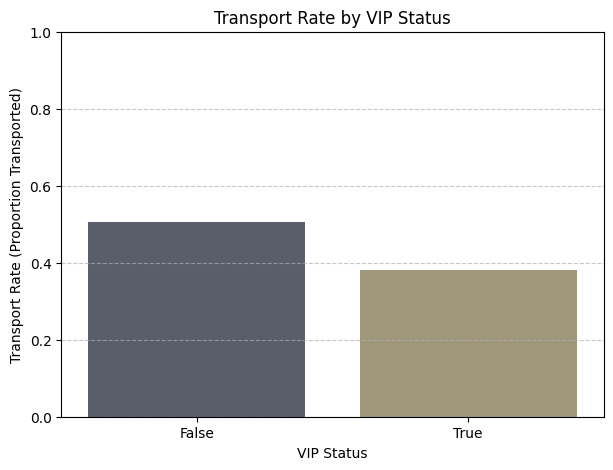

In [ ]:

plt.figure(figsize=(7, 5))
sns.barplot(x='VIP', y='Transported', data=vip_transport_rate, palette='cividis')
plt.title('Transport Rate by VIP Status')
plt.xlabel('VIP Status')
plt.ylabel('Transport Rate (Proportion Transported)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
cryosleep_transport_rate = df.groupby('CryoSleep')['Transported'].mean().reset_index()
display(cryosleep_transport_rate)

,CryoSleep,Transported
0,False,0.335042
1,True,0.817583


This table shows the proportion of transported passengers for those who used CryoSleep and those who did not. A significant difference in these proportions would indicate there is a high correlation of those who used cryosleep and were transported.

/tmp/ipykernel_1654/3137977195.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CryoSleep', y='Transported', data=cryosleep_transport_rate, palette='deep')


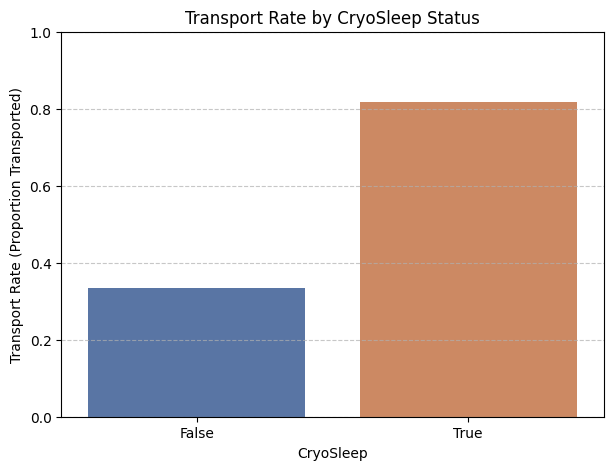

In [ ]:
cryosleep_transport_rate = df.groupby('CryoSleep')['Transported'].mean().reset_index()
plt.figure(figsize=(7, 5))
sns.barplot(x='CryoSleep', y='Transported', data=cryosleep_transport_rate, palette='deep')
plt.title('Transport Rate by CryoSleep Status')
plt.xlabel('CryoSleep')
plt.ylabel('Transport Rate (Proportion Transported)')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for proportion
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Age group among the passengers

In [ ]:
display(df['Age'].head())

,Age
0,39.0
1,24.0
2,58.0
3,33.0
4,16.0


In [ ]:
age_bins = [0, 12, 18, 35, 60, 100] # Child, Teen, Young Adult, Adult, Senior
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)
age_group_counts = df['AgeGroup'].value_counts().reindex(age_labels)
display(age_group_counts)

,count
AgeGroup,
Child,765
Teen,780
Young Adult,4464
Adult,2430
Senior,254


/tmp/ipykernel_1654/3275978906.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='viridis', order=age_labels)


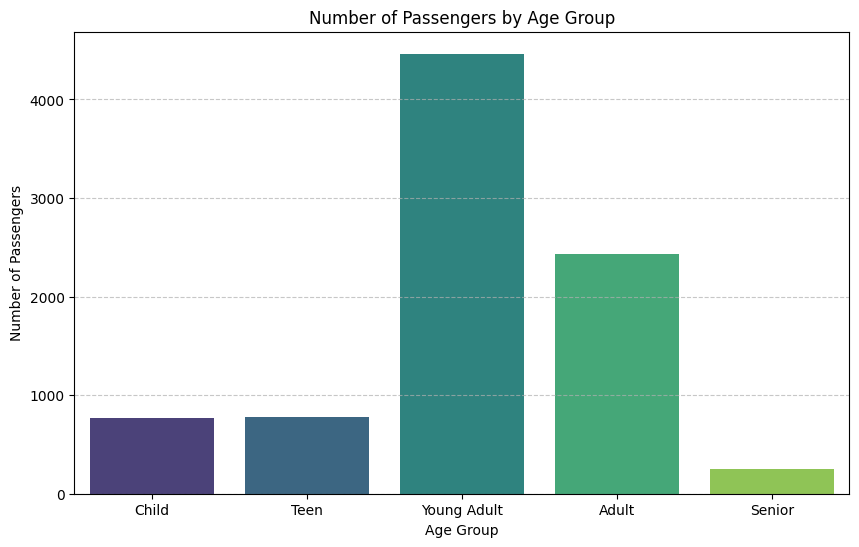

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='viridis', order=age_labels)
plt.title('Number of Passengers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The data show that many of the passengers were Young Adults.

### Correlation between Age and Transported Status

In [ ]:
# Reload the original training data for this specific analysis
df_analysis_temp = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Science Project/train.csv')

# Create age bins for analysis
age_bins = [0, 12, 18, 35, 60, 100] # Child, Teen, Young Adult, Adult, Senior
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

# Create 'AgeGroup' column in the temporary analysis DataFrame
df_analysis_temp['AgeGroup'] = pd.cut(df_analysis_temp['Age'], bins=age_bins, labels=age_labels, right=False)

# Calculate the transport rate by 'AgeGroup'
age_transport_rate = df_analysis_temp.groupby('AgeGroup')['Transported'].mean().reset_index()
display(age_transport_rate)

/tmp/ipykernel_1654/2450057170.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_transport_rate = df_analysis_temp.groupby('AgeGroup')['Transported'].mean().reset_index()


,AgeGroup,Transported
0,Child,0.699346
1,Teen,0.561538
2,Young Adult,0.468145
3,Adult,0.489712
4,Senior,0.468504


/tmp/ipykernel_1654/1605107813.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AgeGroup', y='Transported', data=age_transport_rate, palette='viridis', order=age_labels)


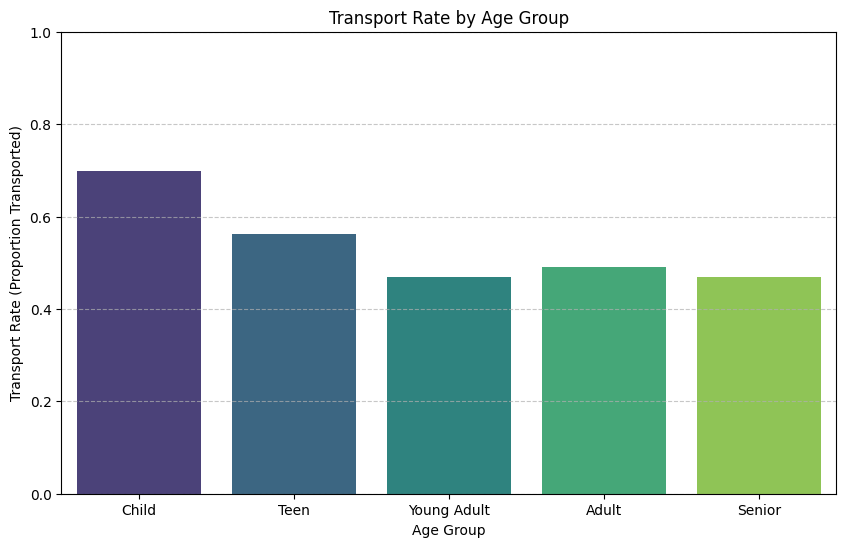

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='AgeGroup', y='Transported', data=age_transport_rate, palette='viridis', order=age_labels)
plt.title('Transport Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Transport Rate (Proportion Transported)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The data shows that children were more likely to be transported than any other age group.  

Let's examine the test data.

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Data Science Project/test (1) (2).csv'
df = pd.read_csv(file_path)
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


### Train-Validation Split for Model Evaluation

Since the provided `test.csv` does not contain the `Transported` column, we cannot use it to evaluate our model's performance directly. Instead, we'll split our `df_train_encoded` (which is the preprocessed original training data) into a new training set and a validation set. This validation set will act as our "unseen data" for evaluating how well our model generalizes before making predictions on the true test data.

In [ ]:
# 1. Reload the original training data to ensure we are working with the correct dataset
df_train_full = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Science Project/train.csv')

# 2. Preprocessing Steps to create df_train_encoded
# Handle missing numerical values with median
numerical_cols = df_train_full.select_dtypes(include=np.number).columns.tolist()
for col in numerical_cols:
    if col != 'Transported': # Don't impute the target
        df_train_full[col].fillna(df_train_full[col].median(), inplace=True)

# Handle missing categorical values with mode
categorical_cols_to_impute = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin']
for col in categorical_cols_to_impute:
    if col in df_train_full.columns:
        df_train_full[col].fillna(df_train_full[col].mode()[0], inplace=True)

# Feature Engineering: Deconstruct Cabin into Deck, Num, Side
df_train_full[['Deck', 'Num', 'Side']] = df_train_full['Cabin'].str.split('/', expand=True)
# Impute missing Deck/Num/Side values with 'Unknown' if the original Cabin was NaN
df_train_full['Deck'].fillna('Unknown', inplace=True)
df_train_full['Num'].fillna('-1', inplace=True) # Use a placeholder for missing numbers
df_train_full['Side'].fillna('Unknown', inplace=True)
df_train_full.drop('Cabin', axis=1, inplace=True) # Drop original Cabin column

# Convert 'Num' column to numeric type
df_train_full['Num'] = pd.to_numeric(df_train_full['Num'], errors='coerce')
# Fill any potential NaNs created by coercion (e.g., if there were non-numeric strings not caught by previous fillna) with median or 0
df_train_full['Num'].fillna(df_train_full['Num'].median(), inplace=True)

# Convert boolean columns to integer (0 or 1)
df_train_full['CryoSleep'] = df_train_full['CryoSleep'].astype(int)
df_train_full['VIP'] = df_train_full['VIP'].astype(int)
df_train_full['Transported'] = df_train_full['Transported'].astype(int) # Target variable

# Drop PassengerId and Name as they are identifiers and not predictive features
df_train_full.drop(['PassengerId', 'Name'], axis=1, inplace=True)

# One-hot encode remaining categorical features
cols_to_encode = ['HomePlanet', 'Destination', 'Deck', 'Side']
df_train_encoded = pd.get_dummies(df_train_full, columns=cols_to_encode, drop_first=True)

# Now, df_train_encoded is ready for splitting
# Split the df_train_encoded into training and validation sets
X = df_train_encoded.drop('Transported', axis=1)
y = df_train_encoded['Transported']

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train_split: {X_train_split.shape}")
print(f"Shape of y_train_split: {y_train_split.shape}")
print(f"Shape of X_val_split: {X_val_split.shape}")
print(f"Shape of y_val_split: {y_val_split.shape}")

Shape of X_train_split: (6954, 21)
Shape of y_train_split: (6954,)
Shape of X_val_split: (1739, 21)
Shape of y_val_split: (1739,)


/tmp/ipykernel_1654/1625397258.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train_full[col].fillna(df_train_full[col].median(), inplace=True)
/tmp/ipykernel_1654/1625397258.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [ ]:
model_split = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_split.fit(X_train_split, y_train_split)

train_split_accuracy = model_split.score(X_train_split, y_train_split)
print(f"New Model Training Data Accuracy (from split): {train_split_accuracy:.4f}")

New Model Training Data Accuracy (from split): 0.9994


In [ ]:
model_split = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_split.fit(X_train_split, y_train_split)

train_split_accuracy = model_split.score(X_train_split, y_train_split)
print(f"New Model Training Data Accuracy (from split): {train_split_accuracy:.4f}")

New Model Training Data Accuracy (from split): 0.9994


In [ ]:
val_accuracy = model_split.score(X_val_split, y_val_split)
print(f"New Model Validation Data Accuracy (from split): {val_accuracy:.4f}")

New Model Validation Data Accuracy (from split): 0.8108


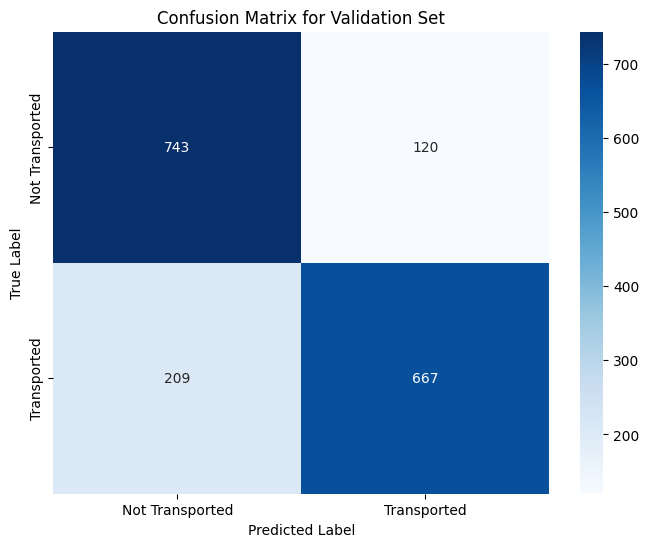

In [ ]:
# Make predictions on the validation set
y_pred_val = model_split.predict(X_val_split)

# Calculate the confusion matrix
cm = confusion_matrix(y_val_split, y_pred_val)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])
plt.title('Confusion Matrix for Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:

# Initialize and train an XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_split, y_train_split)

# Get feature importances from the XGBoost model
xgb_feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train_split.columns).sort_values(ascending=False)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:35:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Show how features impact being transported

Top Features Determining Transportation Profile (XGBoost):


,0
CryoSleep,0.491186
Deck_G,0.128032
HomePlanet_Europa,0.069907
Deck_E,0.044058
Spa,0.025199
HomePlanet_Mars,0.025105
VRDeck,0.023616
Side_S,0.022824
RoomService,0.022370
Deck_F,0.018301


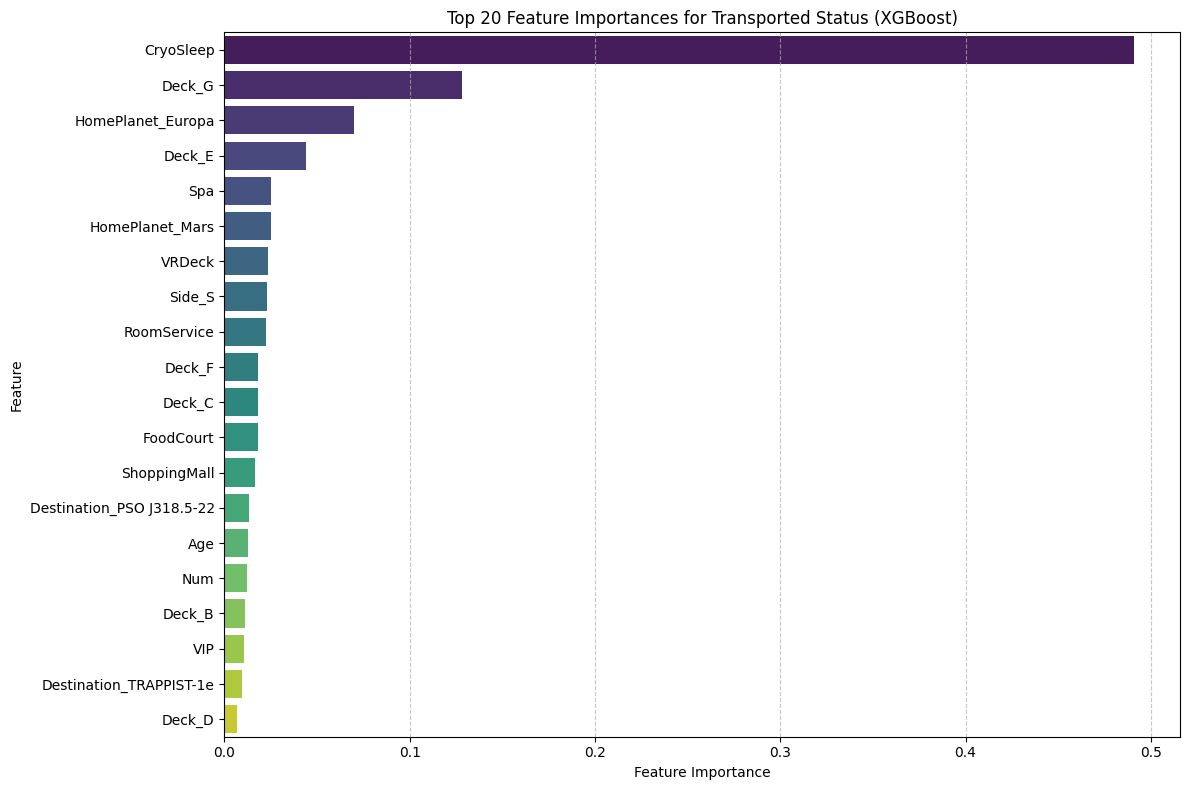

In [ ]:
print("Top Features Determining Transportation Profile (XGBoost):")
display(xgb_feature_importances.head(20))

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=xgb_feature_importances.head(20).values, y=xgb_feature_importances.head(20).index, palette='viridis', hue=xgb_feature_importances.head(20).index, legend=False)
plt.title('Top 20 Feature Importances for Transported Status (XGBoost)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
feature_importances = pd.Series(model_split.feature_importances_, index=X_train_split.columns).sort_values(ascending=False)

Top Features Determining Transportation Profile:


,0
Num,0.181859
Age,0.135887
Spa,0.103132
RoomService,0.099436
VRDeck,0.097017
CryoSleep,0.086033
FoodCourt,0.084921
ShoppingMall,0.071203
HomePlanet_Europa,0.022781
Side_S,0.020606


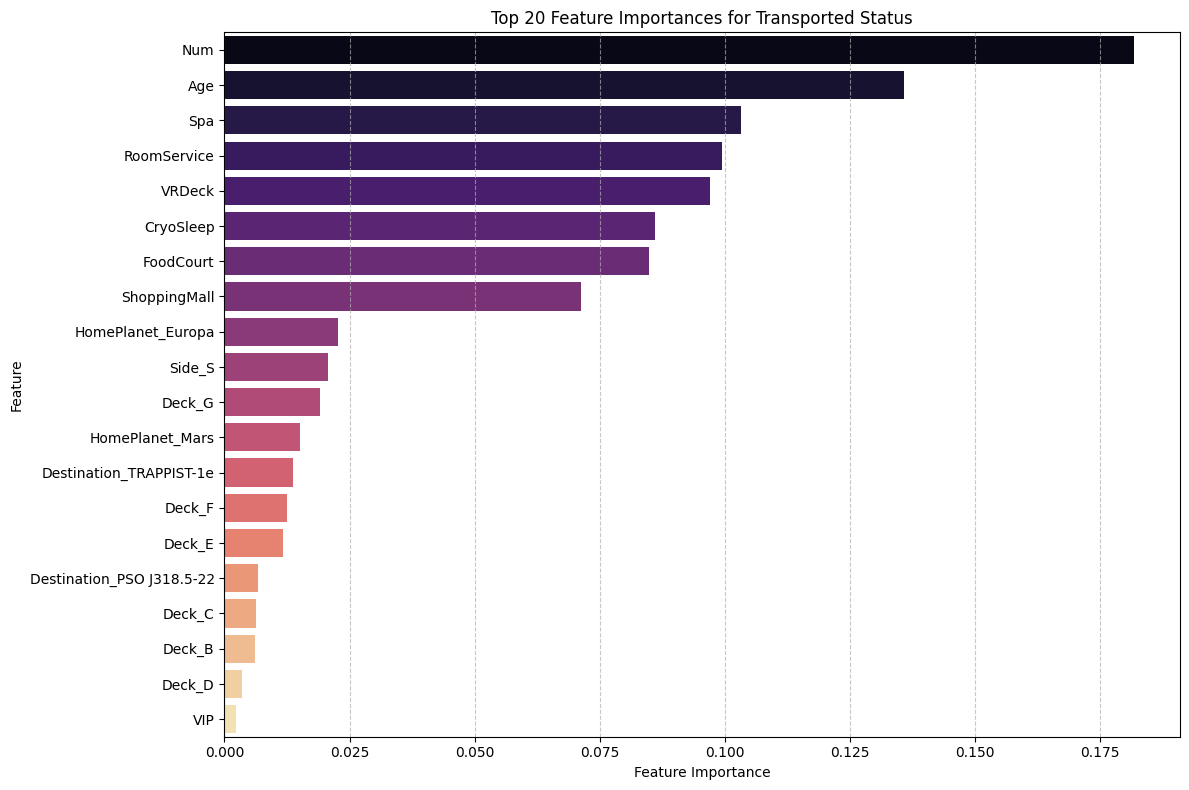

In [ ]:
print("Top Features Determining Transportation Profile:")
display(feature_importances.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.head(20).values, y=feature_importances.head(20).index, palette='magma', hue=feature_importances.head(20).index, legend=False)
plt.title('Top 20 Feature Importances for Transported Status')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
total_passengers = df_train_full.shape[0]
total_transported = df_train_full['Transported'].sum()

print(f"Total Passengers: {total_passengers}")
print(f"Total Transported: {total_transported}")

Total Passengers: 8693
Total Transported: 4378


In [ ]:
transported_distribution = df_train_full['Transported'].value_counts()
display(transported_distribution)

,count
Transported,
1,4378
0,4315


In [ ]:
model_split_tuned = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=10)
model_split_tuned.fit(X_train_split, y_train_split)

train_split_accuracy_tuned = model_split_tuned.score(X_train_split, y_train_split)
val_accuracy_tuned = model_split_tuned.score(X_val_split, y_val_split)

print(f"Tuned Model Training Data Accuracy: {train_split_accuracy_tuned:.4f}")
print(f"Tuned Model Validation Data Accuracy: {val_accuracy_tuned:.4f}")

Tuned Model Training Data Accuracy: 0.8594
Tuned Model Validation Data Accuracy: 0.7941


In [ ]:
test_file_path = '/content/drive/MyDrive/Colab Notebooks/Data Science Project/test (1) (2).csv'
df_test_original = pd.read_csv(test_file_path)

In [ ]:
df_test_original.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [ ]:

# Ensure the correct test data is loaded directly within this cell
df_test_original = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Science Project/test (1) (2).csv')

# Make a copy of the original test data to preserve it for PassengerId
df_test_original_copy = df_test_original.copy()

# --- Preprocessing the test data (mirroring steps in 20a56c7d) ---

# Re-loading train.csv to get imputation values from training data to avoid data leakage
df_train_for_imputation = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Science Project/train.csv')

# Calculate imputation values from training data
numerical_cols_for_imputation = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
imputation_medians = {col: df_train_for_imputation[col].median() for col in numerical_cols_for_imputation}

categorical_cols_for_imputation = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin']
imputation_modes = {col: df_train_for_imputation[col].mode()[0] for col in categorical_cols_for_imputation if col in df_train_for_imputation.columns}

# Apply imputation to test data using training data values
for col, median_val in imputation_medians.items():
    if col in df_test_original_copy.columns: # Check if column exists in test data
        df_test_original_copy[col] = df_test_original_copy[col].fillna(median_val)
for col, mode_val in imputation_modes.items():
    if col in df_test_original_copy.columns: # Check if column exists in test data
        df_test_original_copy[col] = df_test_original_copy[col].fillna(mode_val)

# Feature Engineering: Deconstruct Cabin into Deck, Num, Side
df_test_original_copy[['Deck', 'Num', 'Side']] = df_test_original_copy['Cabin'].str.split('/', expand=True)
df_test_original_copy['Deck'] = df_test_original_copy['Deck'].fillna('Unknown')
df_test_original_copy['Num'] = df_test_original_copy['Num'].fillna('-1') # Use a placeholder for missing numbers
df_test_original_copy['Side'] = df_test_original_copy['Side'].fillna('Unknown')
df_test_original_copy.drop('Cabin', axis=1, inplace=True) # Drop original Cabin column

# Convert 'Num' column to numeric type in test data
df_test_original_copy['Num'] = pd.to_numeric(df_test_original_copy['Num'], errors='coerce')
# Fill any potential NaNs created by coercion with the median of 'Num' from the *processed* training data
# We need to calculate this from df_train_full after its Num column is processed in 20a56c7d
# For simplicity, we'll use a general median from 'Age' as a fallback, or better, re-calculate the `Num` median from df_train_full
# To get the processed Num median from training data, we would need to run the full training preprocessing again or extract it from the kernel's df_train_full. Let's use 0 as a safe fallback here, or better, the median from the 'Num' column of df_train_full (which is already processed in the kernel state)
df_test_original_copy['Num'] = df_test_original_copy['Num'].fillna(df_train_full['Num'].median())

# Convert boolean columns to integer (0 or 1) in test data
df_test_original_copy['CryoSleep'] = df_test_original_copy['CryoSleep'].astype(int)
df_test_original_copy['VIP'] = df_test_original_copy['VIP'].astype(int)

# Drop PassengerId and Name from test data
df_test_original_copy.drop(['PassengerId', 'Name'], axis=1, inplace=True)

# One-hot encode remaining categorical features in test data
cols_to_encode = ['HomePlanet', 'Destination', 'Deck', 'Side']
X_test_processed = pd.get_dummies(df_test_original_copy, columns=cols_to_encode, drop_first=True)

# Align columns with X_train_split (critical for consistent feature set)
# Get columns from X_train_split (from kernel state)
train_cols = X_train_split.columns

# Add missing columns to X_test_processed and fill with 0
missing_cols = set(train_cols) - set(X_test_processed.columns)
for c in missing_cols:
    X_test_processed[c] = 0

# Drop columns from X_test_processed that are not in X_train_split
extra_cols = set(X_test_processed.columns) - set(train_cols)
if len(extra_cols) > 0:
    X_test_processed.drop(columns=list(extra_cols), inplace=True)

# Ensure the order of columns is the same as in X_train_split
X_test_processed = X_test_processed[train_cols]

# --- Make Predictions ---
# Assuming model_split_tuned is the desired model to use for final predictions
test_predictions = model_split_tuned.predict(X_test_processed)

# Convert numerical predictions (0, 1) to boolean (False, True)
predictions_boolean = test_predictions.astype(bool)

# Create a submission DataFrame
submission_df = pd.DataFrame({
    'PassengerId': df_test_original['PassengerId'], # Use original df_test_original for PassengerId
    'Transported': predictions_boolean
})

# Display the first few rows of the submission DataFrame
display(submission_df.head())

/tmp/ipykernel_1654/1899497571.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test_original_copy[col] = df_test_original_copy[col].fillna(mode_val)


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


Based on the data, age (e.g. child), using amenities such as the spa and vrdeck were strong indicators of whether someone was transported.  

The least indicators were Deck D, Teens and Adults.

Overall, the data showed that there were 8,693 passengers aboard with the majority of the passengers were young adults.  Among the 8.693 passengers,4378 were transported.
The data show that a passenger was highly likely to be transported if they were a child or from Europa, in CryoSleep, spending money on amenities, and being located on a 'premium' deck like B or C.Non-VIP passengers were more likely to be transported (roughly 51% than VIP passengers, which was 38%).  

Based up maching learning, the models show that a combination of demographic factors such as age, lifestyle choices and physical attributes such as home planet, and deck are the strongest indicators of whether a person was transported.

Moreover, the confusion matrix was able to predict that 676 passengers were transported and predicted that 698 passengers were not transported with accuracy.



In [ ]:
# Save the submission DataFrame to a CSV file
submission_file_path = '/content/drive/MyDrive/Colab Notebooks/Data Science Project/submission.csv'
submission_df.to_csv(submission_file_path, index=False)

print(f"Submission file saved to: {submission_file_path}")


Submission file saved to: /content/drive/MyDrive/Colab Notebooks/Data Science Project/submission.csv
